In [ ]:
"""
ALGORITMOS GENÉTICOS
MAXIMIZAR UNA FUNCIÓN NO LINEAL... 'DIFÍCIL' ;) CON PYGAD
"""

#importo las bibliotecas necesarias
import matplotlib.pyplot as plt
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip list | grep pygad

In [ ]:
# usando pygad
!pip install pygad
import pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 1.7 MB/s eta 0:00:00


In [ ]:
#   DEFINIMOS LA FUNCIÓN A MAXIMIZAR
def fx(x):
    return -(0.1+(1-x)**2-0.1*math.cos(6*math.pi*(1-x)))+2


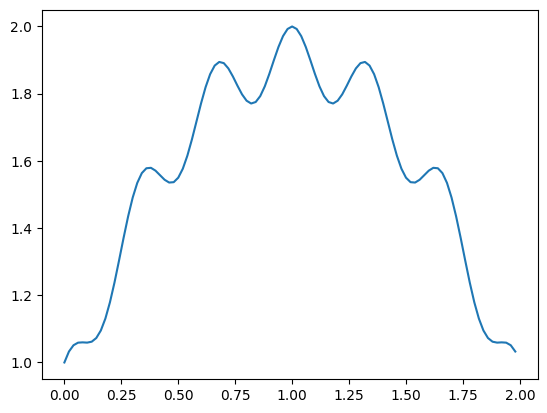

In [ ]:
y_axis = []
x_axis=np.arange(0,2,0.02)

for num in x_axis:
    y_axis.append(fx(num))

plt.plot(x_axis,y_axis)
plt.show()


In [ ]:
# ELEGIMOS CÓMO REPRESENTAR NUESTROS INDIVIDUOS -> LISTAS

def listToDecimal(num):
    decimal=0
    for i in range(len(num)):
        decimal+=num[i]*10**(-i)
    return decimal


In [ ]:
z = [0,5,4]
print(listToDecimal(z))

0.54


In [ ]:
# definir función fitness

def fitness_func(ga_instance, solution, solution_idx):
    x=listToDecimal(solution)
    fitness = fx(x) # Como queremos maximizar la función, ella misma es una buena medida del fitness
    return fitness


In [ ]:
# parámetros que se pueden asignar https://pygad.readthedocs.io/en/latest/pygad.html#other-instance-attributes-methods
'''
If the 2 parameters 'mutation_type' and 'crossover_type' are None, this disables
any type of evolution the genetic algorithm can make.
As a result, the genetic algorithm cannot find a better solution that the best
solution in the initial population.

 '''
ga_instance = pygad.GA(num_generations=1000,
                       sol_per_pop=5,
                       num_genes=15,
                       num_parents_mating=5,
                       fitness_func=fitness_func,
                       mutation_type="random",
                       mutation_probability=0.03,
                       save_solutions = True)

ga_instance.run()
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Parameters of the best solution : \n{solution}")
print(f"Fitness value of the best solution = {solution_fitness}")
print(f"Index of the best solution : {solution_idx}")

Parameters of the best solution : 
[ 1.00983641 -0.67189942  5.05214998  7.35324134 -5.01430741 -2.3811026
  3.50531388  4.84444404  4.86884365 -0.78433852 -1.68650047 -2.3468084
  2.97641675 -1.41795714 -3.1104256 ]
Fitness value of the best solution = 2.0
Index of the best solution : 0


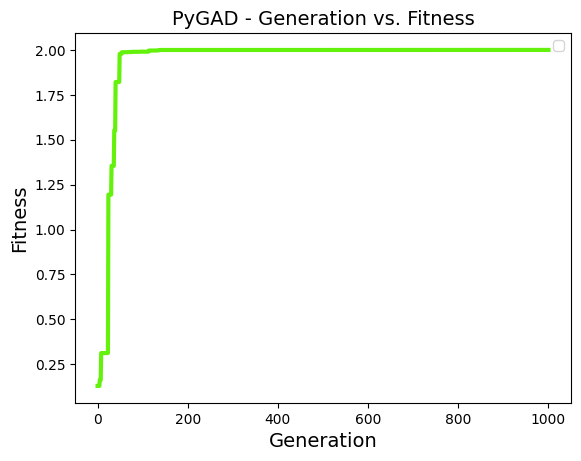

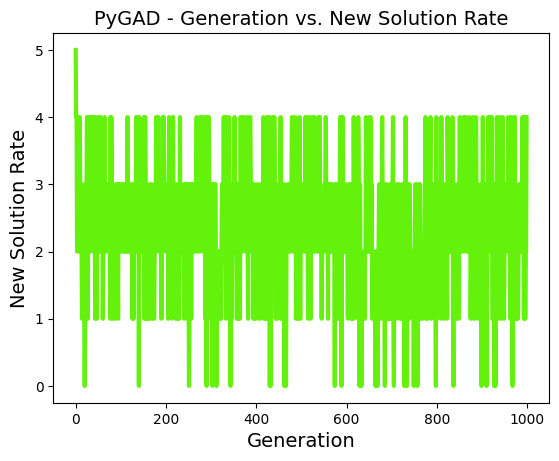

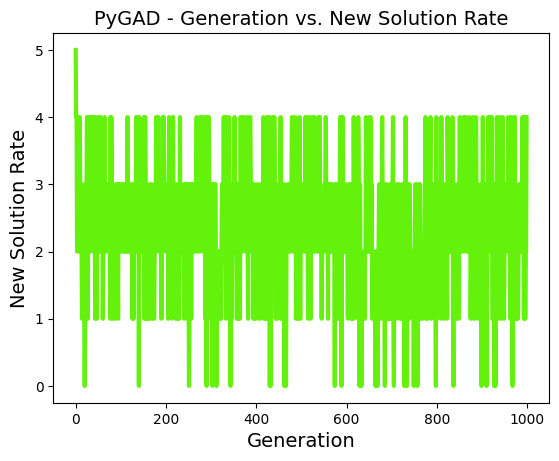

In [ ]:
import matplotlib.pyplot as plt
# plt.close()
ga_instance.plot_fitness()
#ga_instance.plot_genes().  Este método tiene un bug
ga_instance.plot_new_solution_rate()

In [ ]:
ga_instance.plot_genes()

NameError: name 'matplt' is not defined

In [ ]:
ga_instance.best_solution_generation

277

####DEAP

In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.5 MB/s eta 0:00:00


In [ ]:
# Usando deap
# Del Capítulo 1 de "Algoritmos Genéticos con Python" de Daniel Gutiérrez Reina

import random
from deap import base
from deap import creator
from deap import tools
from deap import algorithms


In [ ]:
# Creamos los objetos para definir el problema y el tipo de individuo
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

def funcion_objetivo(individuo):
    """
    Función objetivo de nuestro problema, debe retornar una tupla
    """
    x=listToDecimal(individuo)

    return fx(x),

toolbox = base.Toolbox()


In [ ]:
# Generación de genes
toolbox.register("attr_uniform", random.randint, 0, 9)

# Generación de inviduos y población
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attr_uniform, 15)
toolbox.register("population", tools.initRepeat, list,
                 toolbox.individual, 50)

# Registro de operaciones genéticas
toolbox.register("evaluate", funcion_objetivo)
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu=0,
                 sigma= 5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)


In [ ]:
def plot_evolucion(log):
    """
    Representa la evolución del mejor individuo en cada generación
    """
    gen = log.select("gen")
    fit_mins = log.select("min")
    fit_maxs = log.select("max")
    fit_ave = log.select("avg")

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    '''ax1.fill_between(gen, fit_mins, fit_maxs,
                     where=fit_maxs >= fit_mins, facecolor='g', alpha = 0.2)
    '''
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([0., 2.])
    ax1.legend(["Min", "Max", "Avg"], loc="lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps", dpi = 300)

def main():
    CXPB, MUTPB, NGEN = 0.5, 0.2, 20
    pop = toolbox.population()
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB,
                                       mutpb=MUTPB, ngen=NGEN, stats=stats,
                                       halloffame=hof, verbose=False)
    return hof, logbook



In [ ]:
random.seed(42)
lista_mejores = list()
for i in range(20):
    best, log = main()
    lista_mejores.append(best[0].fitness.values)
media = np.mean(lista_mejores)
mejor_total = max(lista_mejores)
print("media %f" % media)
print("mejor %f" % mejor_total)

media 1.992636
mejor 2.000000


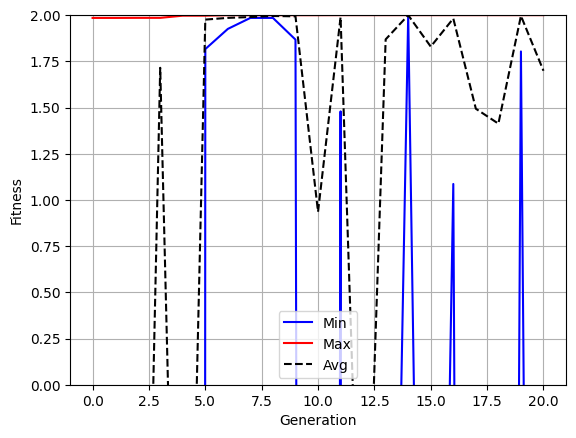

In [ ]:
plot_evolucion(log)